# Bethe-Bloch formula
With the Bethe formula it is possible to calculate the mean energy loss of heavy charged particles per unit length in a material, there are almost as many formulations as there are textbooks.

From Lilley Eq. 5.2
$$
-\frac{dE}{dx} = \left(\frac{ze^2}{4\pi\epsilon_0}\right)^2\ \frac{4\pi Z\rho N_A}{Am_ev^2}\ \left[\ln{\left(\frac{2m_ev^2}{I}\right)} - \ln{\left(1-\beta^2\right)} - \beta^2\right]
$$

we modify it for easier coding as:

$$
-\frac{dE}{dx} = \left(\frac{e^2}{4\pi\epsilon_0}\right)^2\ 
\frac{4\pi z^2}{m_ec^2\beta^2}\ 
\frac{Z\rho N_A}{A}\ \left[\ln{\left(\frac{2m_ec^2\beta^2}{I}\right)} - \ln{\left(1-\beta^2\right)} - \beta^2\right]
$$

Using this simple variable rearranging one can see the terms more clearly as "constants", "incoming radiation properties", and "matter properties". Please have a look at the following table for list of the different terms

In the cell below for your convenience you can find its implementation

In [2]:
import math

def Range_a_in_Air_Empirical(E):
    """
    E in [MeV] or alphas
    
    returns range [cm]
    """
    return 0.318*E**(3/2)

def Energy_a_for_air_Range(R):
    """
    Range in [cm]
    
    returns E [MeV]
    """
    return (R/0.318)**(2/3)

def Bethe_Bloch(E, m0c2, z, A, Z, rho, I=None):
    """
    Projectile:
      - E   [MeV] 
      - mc2 [MeV]
      - z   [e]
    Target:
      - A   [g/mol]
      - Z   [e]
      - rho [g/cm3]
      - I   [eV]
    Returns dE/dx in [MeV/cm]
    """
        
    # If no ionization potential is given try a parameterization
    if I == None:
        if Z < 13:
            I = Z*(12 + 7/Z)  # [eV]
        else:
            I = Z*(9.76+58.8*Z**(-1.19)) # [eV]
    I /= 1e6       # [MeV]

    N_A  = 6.02214086e23 # [1/mole] per gram
    mec2 = 0.511         # [MeV] electrons

    e2_4pi_e0  = 1.4400  # [MeV*fm]
    e2_4pi_e0 /= 1e15    # [MeV*m]
    e2_4pi_e0 *= 100     # [MeV*cm]
    
    def E_to_beta(E, m_c2):
        """
        E    [MeV]
        m_c2 [MeV]
        
        Returns adimentional beta value.
        """
        gamma = (E + m_c2) / m_c2  # total energy over rest mass 
        beta = math.sqrt( 1 - 1/(gamma**2) )
        return beta
    
    def L(beta, mec2, I):
        "The square brackets part"
        el  = math.log(2*mec2*beta**2/I)
        el -= math.log(1 - beta**2)
        el -= beta**2
        return el

    beta = E_to_beta(E, m0c2)

    ## Let's do the Bethe-Block formula step-by-step
    dE_dX  = e2_4pi_e0**2                     # [MeV2*cm2] coulomb-part    
    dE_dX *= 4*math.pi*z**2 / (mec2*beta**2)  # [1/MeV]    projectile
    dE_dX *= Z*rho*N_A/A                      # [1/cm3]    target     
    dE_dX *= L(beta, mec2, I)                 # dimentionless
    # the whole thing is MeV/cm   
    return dE_dX

## Let's plot it

Let's compare the stopping power of charged particles in different materials. For simplicity this comparison is done normalized be the density so once can compare between different material more easily. 

### Protons

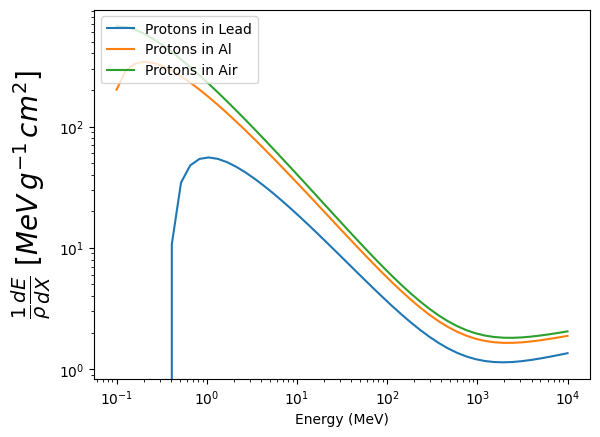

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Proton particle
mc2 = 938.27 # [MeV]
z = 1        # [e]

# impinging on Lead
A = 206.14    # [g/mol] Average molar mass
Z = 82        # [e]     Average charge
rho = 11.348  # [g/cm3]
I = None      # [eV]
E_array = np.logspace(-1, 4, endpoint=True)

## Initial values
dE_dX_array = np.zeros(len(E_array))
for i in range(len(E_array)):
    dE_dX_array[i] = Bethe_Bloch(E_array[i], mc2, z, A, Z, rho, I)

plt.loglog(E_array, dE_dX_array/rho, label=r'Protons in Lead')
plt.legend(loc='upper left')
plt.xlabel(r'Energy (MeV)')
plt.ylabel(r'$\frac{1}{\rho}\frac{dE}{dX}$ $[MeV\,g^{-1}\,cm^{2}]$', size=20)
#plt.savefig("bethe_bloch.svg")

# impinging on Al
A = 26.98     # [g/mol] Average molar mass
Z = 13        # [e]     Average charge
rho = 2.699   # [g/cm3]
I = None      # [eV]
E_array = np.logspace(-1, 4, endpoint=True)

## Initial values
dE_dX_array = np.zeros(len(E_array))
for i in range(len(E_array)):
    dE_dX_array[i] = Bethe_Bloch(E_array[i], mc2, z, A, Z, rho, I)

plt.loglog(E_array, dE_dX_array/rho, label=r'Protons in Al')
plt.legend(loc='upper left')
plt.xlabel(r'Energy (MeV)')
plt.ylabel(r'$\frac{1}{\rho}\frac{dE}{dX}$ $[MeV\,g^{-1}\,cm^{2}]$', size=20)
#plt.savefig("bethe_bloch.svg")

# impinging on Air
A = 28.96     # [g/mol] Average molar mass
Z = 14.46     # [e]     Average charge
rho = 0.0012  # [g/cm3]
I = 86        # [eV]
E_array = np.logspace(-1, 4, endpoint=True)

## Initial values
dE_dX_array = np.zeros(len(E_array))
for i in range(len(E_array)):
    dE_dX_array[i] = Bethe_Bloch(E_array[i], mc2, z, A, Z, rho, I)

plt.loglog(E_array, dE_dX_array/rho, label=r'Protons in Air')
plt.legend(loc='upper left')
plt.xlabel(r'Energy (MeV)')
plt.ylabel(r'$\frac{1}{\rho}\frac{dE}{dX}$ $[MeV\,g^{-1}\,cm^{2}]$', size=20)
plt.savefig("protons_in_aluminum.png")

### Alpha particles

Text(0, 0.5, '$\\frac{1}{\\rho}\\frac{dE}{dX}$ $[MeV\\,g^{-1}\\,cm^{2}]$')

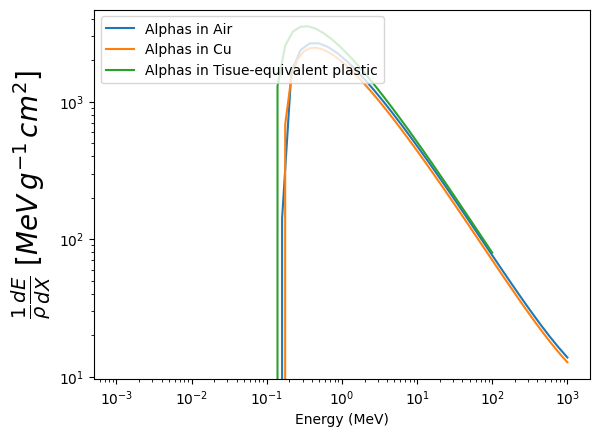

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## Alpha particle
mc2 = 3727.379 # [MeV]
z = 2          # [e]

# impinging on Air
A = 28.96     # [g/mol] Average molar mass
Z = 14.46     # [e]     Average charge
rho = 0.0012  # [g/cm3]
#I = 86        # [eV]
E_array = np.logspace(-3, 3, endpoint=True)

## Initial values
dE_dX_array = np.zeros(len(E_array))
for i in range(len(E_array)):
    dE_dX_array[i] = Bethe_Bloch(E_array[i], mc2, z, A, Z, rho, I)

#plt.semilogx(E_array, dE_dX_array/rho, label=r'Alphas in Air')
plt.loglog(E_array, dE_dX_array/rho, label=r'Alphas in Air')
plt.legend(loc='upper left')
plt.xlabel(r'Energy (MeV)')
plt.ylabel(r'$\frac{1}{\rho}\frac{dE}{dX}$ $[MeV\,g^{-1}\,cm^{2}]$', size=20)
#plt.savefig("bethe_bloch.svg")

# Copper
A = 63        # [g/mol] Average molar mass
Z = 29        # [e]     Average charge
rho = 8.935   # [g/cm3]
E_array = np.logspace(-1, 3, endpoint=True)

## Initial values
dE_dX_array = np.zeros(len(E_array))
for i in range(len(E_array)):
    dE_dX_array[i] = Bethe_Bloch(E_array[i], mc2, z, A, Z, rho, I)

#plt.semilogx(E_array, dE_dX_array/rho, label=r'Alphas in Air')
plt.semilogx(E_array, dE_dX_array/rho, label=r'Alphas in Cu')
plt.legend(loc='upper left')
plt.xlabel(r'Energy (MeV)')
plt.ylabel(r'$\frac{1}{\rho}\frac{dE}{dX}$ $[MeV\,g^{-1}\,cm^{2}]$', size=20)
#plt.savefig("bethe_bloch.svg")

# A-150 Tisue-equivalent plastic
A = 12
Z = 6
rho = 1.12
I = 65.1
E_array = np.logspace(-3, 2, endpoint=True)

## Initial values
dE_dX_array = np.zeros(len(E_array))
for i in range(len(E_array)):
    dE_dX_array[i] = Bethe_Bloch(E_array[i], mc2, z, A, Z, rho, I)

#plt.semilogx(E_array, dE_dX_array/rho, label=r'Alphas in Air')
plt.semilogx(E_array, dE_dX_array/rho, label=r'Alphas in Tisue-equivalent plastic')
plt.legend(loc='upper left')
plt.xlabel(r'Energy (MeV)')
plt.ylabel(r'$\frac{1}{\rho}\frac{dE}{dX}$ $[MeV\,g^{-1}\,cm^{2}]$', size=20)
#plt.savefig("bethe_bloch.svg")


## Exercise - Finding the range of alpha particles in air

We can find numerically the range of a charged particle in matter simply by doing this in a loop:

Does the particle have kinetic energy?
- If yes, then decrease the energy based on the distance we traveled using the Bethe-Bloch formula at the current kinetic energy. This means, 
  - a new energy
  - and a new depth.

NOTE that the natural units of $dE/dx$ as used before are MeV/cm meaning the charged particle loses those MeV per cm traveled. This distance is perhaps useful at high-energy physics but at nuclear-physics energies it is simply too HUGE and therefore not useful. **Word of advice... before using the formula, perform a *simple* unit conversion to MeV/um or even eV/um**.


Alpha of 3.5 MeV stopped/slowed to 0.1568 MeV after 22812 um


Text(0, 0.5, '$\\frac{dE}{dX}$ $[eV/\\mu m]$')

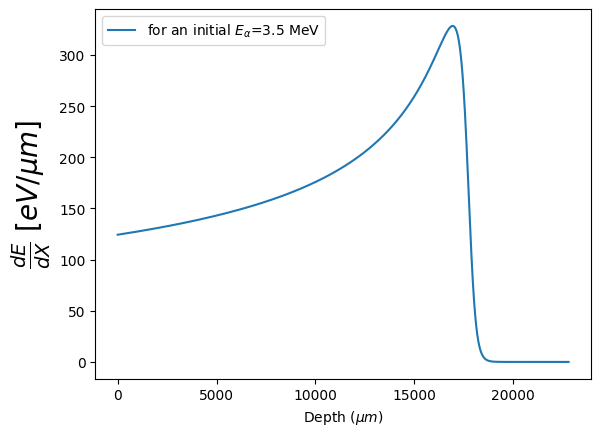

In [5]:

## Alpha particle
E = 3.5        # [MeV] 
mc2 = 3727.379 # [MeV]
z = 2

# impinging on Air
A = 28.96      # [g/mol]
Z = 14.46      # [e]
rho = 1.225e-3 # [g/cm3]
I = 86         # [eV]

# impinging on Al
#A = 27      # [g/mol]
#Z = 13      # [e]
#rho = 2.710 # g/cm3
#I=None

# impinging on Si
#A = 28.1    # [g/mol]
#Z = 14      # [e]
#rho = 2.328 # [g/cm3]
#I=None

# impinging on Gold
#A = 196.97 # [g/mol]
#Z = 79     # [e]
#rho=19.3   # [g/cm3]
#I=None

# impinging on water (fingerprint)
#A = 18.02 # [g/mol]
#Z = 7.42  # [e]
#rho = 1   # [g/cm3]
#I=None

## advancing 1 micron at a time
step = []
brag = []
energy = []
d = 0

target_E = 0
exp_range = 2.0 # [cm]
#target_E = Energy_a_for_air_Range(exp_range)

step.append(d)
energy.append(E)
while E > target_E + 0.01:
    dE_dX  = Bethe_Bloch(E, mc2, z, A, Z, rho, I) # [MeV/cm]
    dE_dX /= 1e4 # [MeV/um]
    #print(dE_dX)
    if dE_dX > 0:      
        E -= dE_dX
        d += 1       # in um
        step.append(d)
        brag.append(dE_dX)
        energy.append(E)
    else:
        break

print(f'Alpha of {energy[0]:.4} MeV stopped/slowed to {energy[-1]:.4} MeV after {d} um')

# turn those lists into array so we can do math with them =)
energy = np.array(energy)
brag = np.array(brag)

plt.plot(step[:-1], brag*1e6, label=r'for an initial $E_\alpha$=3.5 MeV')# from $^{241}$Am in Air')
plt.legend(loc='upper left')
plt.xlabel(r'Depth ($\mu m$)')
plt.ylabel(r'$\frac{dE}{dX}$ $[eV/\mu m]$', size=20)
#plt.savefig("bethe_bloch.svg")

Text(0, 0.5, '$E [MeV]$')

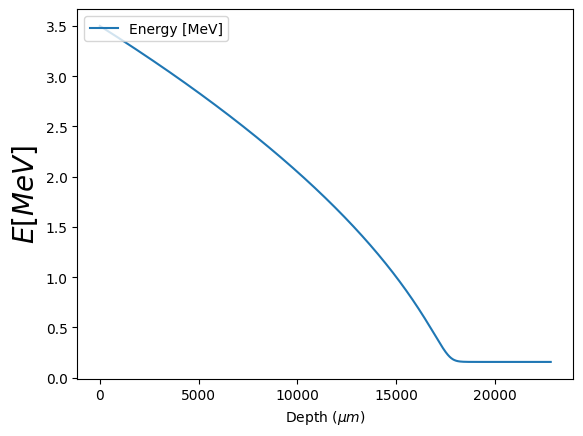

In [6]:
plt.plot(step, energy, label='Energy [MeV]')
plt.legend(loc='upper left')
plt.xlabel(r'Depth ($\mu m$)')
plt.ylabel(r'$E [MeV]$', size=20)
#plt.savefig("bethe_bloch.svg")